# Alt-F4 | Explainable Logistics Decision Intelligence

Task1 service time and lateness, Task2A ten-week demand, and Task2B peak-day allocation.

The complete implementation is in `waypoint_datathon.py`. This notebook executes label/feature inspection, reads actual stored evaluation results and loads saved models for inference. Set `RUN_TRAINING=True` to run the training cells again. The included results were trained by the Python module, not fabricated notebook outputs.

All predictive models are trained from scratch on organizer data. Review `AI_DISCLOSURE.md`. The three tasks have distinct horizons; they support one operational workflow, not one jointly optimized route plan. The verified submission predictions remain frozen during the supplementary analysis.

In [1]:
from pathlib import Path
from types import SimpleNamespace
import os, json
import pandas as pd
import numpy as np
import waypoint_datathon as w
from IPython.display import display, Image, Markdown

DATA_DIR = Path(os.environ.get('WAYPOINT_DATA', 'data'))
OUTPUT_DIR = Path(os.environ.get('WAYPOINT_OUTPUT', 'outputs'))
RUN_TRAINING = False
data = w.Data(DATA_DIR)
args = SimpleNamespace(preset='balanced', jobs=4, allocator_seconds=120, priority_config=None, checker='check_allocation.py')
for name in ('models', 'reports', 'submissions'):
    (OUTPUT_DIR / name).mkdir(parents=True, exist_ok=True)
print('Data ready:', len(data.paths), 'organizer CSVs')

Data ready: 17 organizer CSVs


## 1. Data checks

Orders are unique by delivery ID. Dispatched orders and route legs are one-to-one by route/sequence. Reference joins must match. Input hashes and row counts make the run reproducible.

In [2]:
manifest = pd.DataFrame(data.manifest())
display(manifest[['file', 'rows', 'bytes']])
display(data.read('deliveries_train.csv').head(3))

,file,rows,bytes
0,Training Data/deliveries_train.csv,92307,13305352
1,Training Data/route_legs_train.csv,91894,12083037
2,Test Data/task1_test_inputs.csv,5014,723979
3,Test Data/route_legs_test.csv,5014,553931
4,Test Data/task2a_test_inputs.csv,60,1727
5,Test Data/task2b_peak_day_scenarios.csv,85,8655
6,Test Data/task2b_peak_day_fleet.csv,38,807
7,General Data/outlets.csv,120,7364
8,General Data/vehicles.csv,60,3372
9,General Data/calendar.csv,910,36456


,delivery_id,order_date,dispatch_date,dispatch_status,outlet_id,brand,district,depot,temp_requirement,order_units,order_weight_kg,order_volume_m3,route_id,seq_in_route,vehicle_id,vehicle_type,vehicle_temp,planned_arrival_time,window_open_time,window_close_time
0,ORD0000001,2024-01-01,2024-01-01,attempted,OUT001,Fresh,Colombo,Peliyagoda,ambient,8,71.1,0.402,R000015,0.0,VEH037,van,ambient,05:00,05:00,07:30
1,ORD0000002,2024-01-01,2024-01-01,attempted,OUT002,Fresh,Colombo,Peliyagoda,ambient,15,101.0,0.564,R000015,2.0,VEH037,van,ambient,05:49,05:30,08:00
2,ORD0000003,2024-01-01,2024-01-01,attempted,OUT003,Fresh,Colombo,Peliyagoda,ambient,15,91.2,0.552,R000015,1.0,VEH037,van,ambient,05:25,05:00,07:30


## 2. Label construction

Handling begins at the later of actual arrival and window opening.

`service_min = leave_outlet - max(arrival, window_open)`

`is_late = arrival > window_close`

Never-dispatched orders have no service labels. Arrival exactly at close is not late.

In [3]:
orders = data.read('deliveries_train.csv')
legs = data.read('route_legs_train.csv')
joined = orders.loc[orders.dispatch_status.ne('not_run')].merge(legs, left_on=['route_id','seq_in_route'], right_on=['route_id','seq'], suffixes=('', '_leg'), validate='one_to_one')
arrival = w.minutes(joined.arrival_time)
opening = w.minutes(joined.window_open_time)
closing = w.minutes(joined.window_close_time)
leaving = w.minutes(joined.leave_outlet_time)
joined['service_min'] = leaving - np.maximum(arrival, opening)
joined['is_late'] = (arrival > closing).astype(int)
assert joined.service_min.ge(0).all()
print('Early-arrival example: arrival 08:40, window opens 09:00, leave 09:12 -> service 12 minutes; waiting 20 minutes.')
display(joined[['delivery_id','arrival_time','window_open_time','window_close_time','leave_outlet_time','service_min','is_late']].head(10))

Early-arrival example: arrival 08:40, window opens 09:00, leave 09:12 -> service 12 minutes; waiting 20 minutes.


,delivery_id,arrival_time,window_open_time,window_close_time,leave_outlet_time,service_min,is_late
0,ORD0000001,05:21,05:00,07:30,05:29,8.0,0
1,ORD0000002,06:03,05:30,08:00,06:13,10.0,0
2,ORD0000003,05:41,05:00,07:30,05:52,11.0,0
3,ORD0000004,06:29,05:30,08:00,06:41,12.0,0
4,ORD0000005,06:15,04:00,07:45,06:25,10.0,0
5,ORD0000006,06:37,03:00,08:00,06:49,12.0,0
6,ORD0000007,05:55,03:00,08:00,06:11,16.0,0
7,ORD0000008,06:59,05:30,08:00,07:12,13.0,0
8,ORD0000009,06:26,05:30,08:00,06:45,19.0,0
9,ORD0000010,05:02,05:00,07:30,05:09,7.0,0


## 3. Planned features and chronological validation

Actual outcome columns are removed before feature building. Features include load, outlet access, planned time/slack, known calendar/road conditions and cumulative preceding planned stops. Two four-week tuning folds precede an untouched six-week holdout. Early stopping and ensemble weights use tuning folds only.

In [4]:
X, service_y, late_y, metadata = w.construct_task1(data, training=True)
assert not any(c.startswith('actual_') or c in {'arrival_time','leave_outlet_time','route_id','delivery_id'} for c in X)
print('Labeled rows:', len(X), 'Features:', X.shape[1], 'Late prevalence:', round(late_y.mean(), 4))
display(X.head(3))
display(pd.DataFrame(w.model_specs(args.preset)))

Labeled rows: 91894 Features: 76 Late prevalence: 0.1958


,outlet_id,brand,district,depot,temp_requirement,order_units,order_weight_kg,order_volume_m3,seq_in_route,vehicle_type,vehicle_temp,distance_km,planned_travel_duration_min,dock_type,parking_constraint,weight_cap_kg,volume_cap_m3,km_per_l,weekly_fuel_quota_l,road_class,free_flow_kmh,depot_to_district_km,depot_to_district_freeflow_min,inter_stop_km,inter_stop_freeflow_min,dow,is_weekend,is_payday,festival,festival_ramp,is_holiday,monsoon,is_operating,disruption_index,service_allowance_min,planned_arrival_time_minutes,planned_depart_time_minutes,window_open_time_minutes,window_close_time_minutes,hour,speed_index,planned_slack_min,planned_wait_min,window_width_min,traffic_adjusted_travel,extra_travel_estimate,order_to_dispatch_days,month,day_of_month,annual_sin,annual_cos,weight_per_unit,volume_per_unit,density,log_order_units,log_order_weight_kg,log_order_volume_m3,weight_fraction,volume_fraction,route_stops,route_start_min,planned_elapsed_min,prior_order_units,prior_order_weight_kg,prior_order_volume_m3,prior_service_allowance_min,prior_planned_travel_duration_min,prior_traffic_adjusted_travel,prior_extra_travel_estimate,prior_planned_wait_min,route_order_weight_kg,route_order_volume_m3,accumulated_traffic_slack,brand_dock,district_hour,brand_temp
0,OUT001,Fresh,Colombo,Peliyagoda,ambient,8,71.1,0.402,0,van,ambient,13.7,27,street,van_only,1100,8.0,11.5,340,urban,30.0,12,24,4.0,8,0,0,0,none,0.0,0,0,1,100,16,300.0,273.0,300.0,450.0,4,89,150.0,0.0,150.0,30.337079,3.337079,0,1,1,0.017202,0.999852,8.887500,0.05025,176.865672,2.197225,4.278054,0.337900,0.064636,0.05025,3,273.0,27.0,0,0.0,0.000,0,0,0.000000,0.000000,0.0,263.3,1.518,146.662921,Fresh:street,Colombo:4,Fresh:ambient
1,OUT002,Fresh,Colombo,Peliyagoda,ambient,15,101.0,0.564,2,van,ambient,3.8,8,street,van_only,1100,8.0,11.5,340,urban,30.0,12,24,4.0,8,0,0,0,none,0.0,0,0,1,100,16,349.0,341.0,330.0,480.0,5,79,131.0,0.0,150.0,10.126582,2.126582,0,1,1,0.017202,0.999852,6.733333,0.03760,179.078014,2.772589,4.624973,0.447247,0.091818,0.07050,3,273.0,76.0,23,162.3,0.954,32,36,41.729484,5.729484,0.0,263.3,1.518,123.143934,Fresh:street,Colombo:5,Fresh:ambient
2,OUT003,Fresh,Colombo,Peliyagoda,ambient,15,91.2,0.552,1,van,ambient,4.6,9,street,van_only,1100,8.0,11.5,340,urban,30.0,12,24,4.0,8,0,0,0,none,0.0,0,0,1,100,16,325.0,316.0,300.0,450.0,5,79,125.0,0.0,150.0,11.392405,2.392405,0,1,1,0.017202,0.999852,6.080000,0.03680,165.217391,2.772589,4.523960,0.439544,0.082909,0.06900,3,273.0,52.0,8,71.1,0.402,16,27,30.337079,3.337079,0.0,263.3,1.518,119.270516,Fresh:street,Colombo:5,Fresh:ambient


,name,family,depth,learning_rate,l2_leaf_reg,iterations,num_leaves,reg_lambda,min_child_samples,max_leaf_nodes,l2_regularization,min_samples_leaf,alpha,max_depth,subsample,colsample_bytree,max_features
0,catboost_depth6,catboost,6.0,0.045,5.0,1100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lightgbm_leaves31,lightgbm,NaN,0.040,NaN,1100.0,31.0,5.0,45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,hist_leaves31,hist,NaN,0.060,NaN,400.0,NaN,NaN,NaN,31.0,8.0,45.0,NaN,NaN,NaN,NaN,NaN
3,linear_baseline,ridge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN
4,catboost_depth8,catboost,8.0,0.040,8.0,1100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,lightgbm_leaves63,lightgbm,NaN,0.035,NaN,1100.0,63.0,15.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,xgboost_depth5,xgboost,NaN,0.040,NaN,1100.0,NaN,10.0,NaN,NaN,NaN,NaN,NaN,5.0,0.9,0.9,NaN
7,extra_trees,extra,NaN,NaN,NaN,180.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,0.85


In [5]:
if RUN_TRAINING:
    task1_results = w.run_task1(data, OUTPUT_DIR, args)
else:
    task1_results = json.loads((OUTPUT_DIR / 'reports/task1_metrics.json').read_text())
display(pd.DataFrame([{'target': t, **task1_results[t]['holdout_metrics']} for t in ['service','lateness']]))
display(pd.read_csv(OUTPUT_DIR / 'reports/task1_leaderboard.csv'))

,target,mae,rmse,r2,wape,smape,log_loss,brier,roc_auc,pr_auc,accuracy_at_0.5
0,service,3.752356,6.042708,0.829909,0.203924,0.207136,NaN,NaN,NaN,NaN,NaN
1,lateness,NaN,NaN,NaN,NaN,NaN,0.132287,0.041128,0.975275,0.868734,0.944985


,target,model,stage,seconds,mae,rmse,r2,wape,smape,log_loss,brier,roc_auc,pr_auc,accuracy_at_0.5
0,service,catboost_depth6,tuning,87.78,4.081046,7.133131,0.791561,0.207148,0.207146,NaN,NaN,NaN,NaN,NaN
1,service,lightgbm_leaves31,tuning,13.08,4.134169,7.247625,0.784816,0.209844,0.209085,NaN,NaN,NaN,NaN,NaN
2,service,hist_leaves31,tuning,11.45,4.134042,7.223710,0.786233,0.209838,0.209137,NaN,NaN,NaN,NaN,NaN
3,service,linear_baseline,tuning,2.29,4.445403,7.294170,0.782043,0.225642,0.230850,NaN,NaN,NaN,NaN,NaN
4,service,catboost_depth8,tuning,143.28,4.063953,7.225671,0.786117,0.206280,0.205857,NaN,NaN,NaN,NaN,NaN
5,service,lightgbm_leaves63,tuning,14.70,4.150944,7.264650,0.783803,0.210696,0.209959,NaN,NaN,NaN,NaN,NaN
6,service,xgboost_depth5,tuning,10.34,4.151535,7.320912,0.780442,0.210726,0.210173,NaN,NaN,NaN,NaN,NaN
7,service,extra_trees,tuning,55.69,4.354399,7.558749,0.765944,0.221023,0.218706,NaN,NaN,NaN,NaN,NaN
8,service,frozen_ensemble,holdout,NaN,3.752356,6.042708,0.829909,0.203924,0.207136,NaN,NaN,NaN,NaN,NaN
9,lateness,catboost_depth6,tuning,89.51,NaN,NaN,NaN,NaN,NaN,0.147876,0.045835,0.978053,0.921879,0.934379


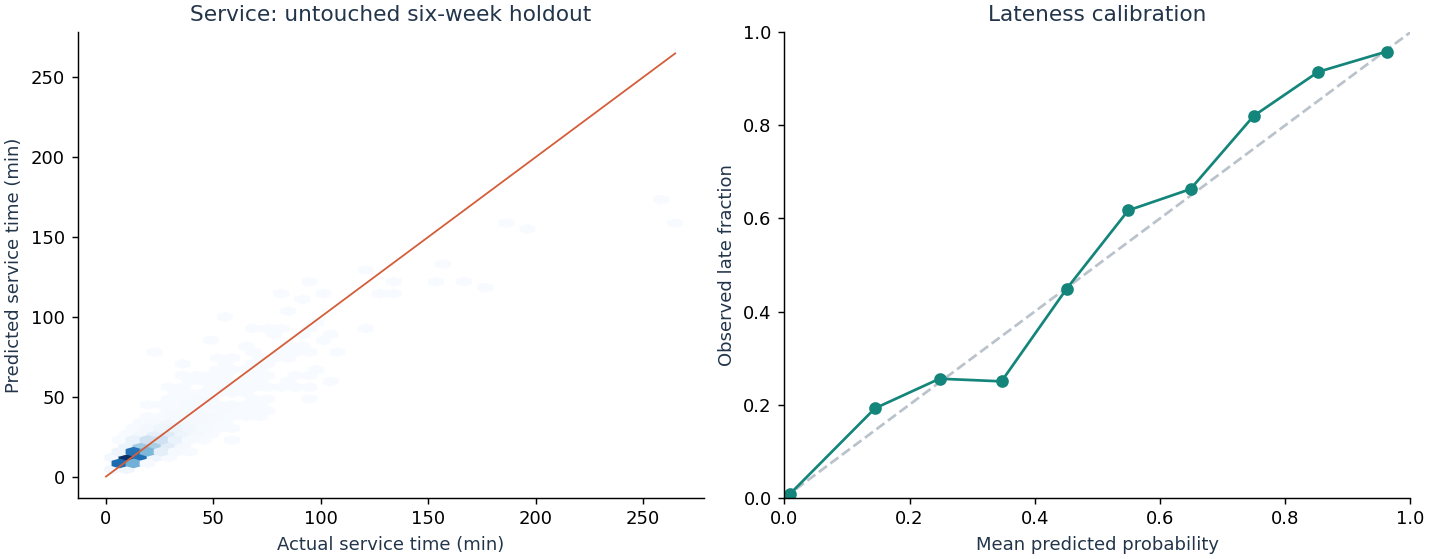

In [6]:
if (OUTPUT_DIR / 'reports/task1_validation.png').exists():
    display(Image(filename=str(OUTPUT_DIR / 'reports/task1_validation.png')))

In [7]:
print('TASK1 VALIDATION DATES')
display(pd.DataFrame(task1_results['tuning_windows'], columns=['tuning_start', 'tuning_end']))
print('Final holdout:', task1_results['holdout'])
slices = pd.read_csv(OUTPUT_DIR / 'reports/task1_by_brand_depot.csv')
display(slices.query("target == 'service' and slice == 'depot+brand'")[['depot','brand','n','mae','rmse']].round(3))
display(slices.query("target == 'lateness' and slice == 'depot+brand'")[['depot','brand','n','late_count','roc_auc','log_loss']].round(4))

TASK1 VALIDATION DATES
Final holdout: ['2026-01-04', '2026-02-14']


,tuning_start,tuning_end
0,2025-11-09,2025-12-06
1,2025-12-07,2026-01-03


,depot,brand,n,mae,rmse
5,Kandy,Fresh,1860,3.331,4.881
6,Kandy,Style,54,9.220,12.936
7,Kandy,Tech,33,15.267,27.085
8,Peliyagoda,Fresh,2929,3.376,4.725
9,Peliyagoda,Style,96,10.445,15.205
10,Peliyagoda,Tech,63,12.805,17.222


,depot,brand,n,late_count,roc_auc,log_loss
16,Kandy,Fresh,1860,288.0,0.9588,0.1813
17,Kandy,Style,54,1.0,0.9623,0.0600
18,Kandy,Tech,33,2.0,0.9677,0.0937
19,Peliyagoda,Fresh,2929,363.0,0.9831,0.1078
20,Peliyagoda,Style,96,5.0,0.9912,0.0551
21,Peliyagoda,Tech,63,1.0,1.0000,0.0222


## 4. Order-date demand and ten-week forecasting

Count all training orders plus Task1 test orders once, including deferred/not-run. Group with the supplied calendar's ISO year/week. Complete zero-filled daily panels sum exactly to source order demand. Forecasts use known calendar context and frozen-origin historical baselines; no future actual demand enters validation. Tune on two ten-week horizons, assess the final ten weeks, then refit.

In [8]:
history, future_days, future_keys, demand_audit = w.demand_panel(data)
display(pd.Series(demand_audit, name='audit'))
display(w.weekly_context(history).tail(12))
print('Forecast weeks:', future_keys.week_start.nunique())
display(future_keys.head(6))

Forecast weeks: 10


orders_counted                                                  97321
not_run_orders_counted                                            413
deferred_orders_counted                                          1633
historical_weeks                                                  117
last_order_date                                            2026-03-28
demand_date                                                order_date
weekly_keys                     calendar.iso_year + calendar.iso_week
task1_inputs_used_for_demand                                     5014
Name: audit, dtype: object

,depot,brand,iso_year,iso_week,week_start,total,chilled,is_operating,is_payday,festival_ramp,is_holiday,monsoon,week_sin,week_cos,series
690,Peliyagoda,Tech,2026,2,2026-01-05,35.666,0.0,6,0,2.1,0,0.000000,0.238517,0.971138,Peliyagoda:Tech
691,Peliyagoda,Tech,2026,3,2026-01-12,29.718,0.0,6,0,3.4,1,0.000000,0.353452,0.935453,Peliyagoda:Tech
692,Peliyagoda,Tech,2026,4,2026-01-19,36.149,0.0,6,1,0.0,0,0.000000,0.463267,0.886219,Peliyagoda:Tech
693,Peliyagoda,Tech,2026,5,2026-01-26,40.281,0.0,6,1,0.0,0,0.000000,0.566372,0.824150,Peliyagoda:Tech
694,Peliyagoda,Tech,2026,6,2026-02-02,56.524,0.0,6,0,0.0,0,0.000000,0.661275,0.750144,Peliyagoda:Tech
695,Peliyagoda,Tech,2026,7,2026-02-09,35.417,0.0,6,0,0.0,0,0.000000,0.746600,0.665274,Peliyagoda:Tech
696,Peliyagoda,Tech,2026,8,2026-02-16,23.253,0.0,6,0,0.0,0,0.000000,0.821111,0.570768,Peliyagoda:Tech
697,Peliyagoda,Tech,2026,9,2026-02-23,40.091,0.0,6,2,0.0,0,0.142857,0.883731,0.467996,Peliyagoda:Tech
698,Peliyagoda,Tech,2026,10,2026-03-02,22.986,0.0,6,0,0.0,0,1.000000,0.933551,0.358445,Peliyagoda:Tech
699,Peliyagoda,Tech,2026,11,2026-03-09,21.290,0.0,6,0,0.0,0,1.000000,0.969850,0.243703,Peliyagoda:Tech


,row_id,depot,brand,iso_year,iso_week,week_start
0,W0000,Kandy,Fresh,2026,14,2026-03-30
1,W0001,Kandy,Style,2026,14,2026-03-30
2,W0002,Kandy,Tech,2026,14,2026-03-30
3,W0003,Peliyagoda,Fresh,2026,14,2026-03-30
4,W0004,Peliyagoda,Style,2026,14,2026-03-30
5,W0005,Peliyagoda,Tech,2026,14,2026-03-30


In [9]:
if RUN_TRAINING:
    demand_results = w.run_task2a(data, OUTPUT_DIR, args)
else:
    demand_results = json.loads((OUTPUT_DIR / 'reports/task2a_metrics.json').read_text())
display(pd.DataFrame([{'target': t, **demand_results[t]['holdout_metrics']} for t in ['total','chilled']]))
display(pd.DataFrame(demand_results['total']['holdout_by_series']).T)
display(pd.read_csv(OUTPUT_DIR / 'reports/task2a_leaderboard.csv').query("stage != 'tuning_series'"))

,target,mae,rmse,r2,wape,smape
0,total,18.112718,28.614784,0.993373,0.060833,0.137638
1,chilled,14.299986,17.737323,0.957924,0.052398,0.050014


,mae,rmse,r2,wape,smape
Kandy:Fresh,24.222641,26.762514,-1.275777,0.046547,0.047267
Kandy:Style,7.982504,13.723268,0.014243,0.099326,0.091893
Kandy:Tech,5.137377,6.821746,-0.707277,0.246680,0.249647
Peliyagoda:Fresh,49.811129,58.578838,-0.646072,0.050571,0.051082
Peliyagoda:Style,11.181684,18.752648,0.018175,0.076983,0.073489
Peliyagoda:Tech,10.340971,13.364013,-0.790598,0.298270,0.312450


,target,model,stage,mae,rmse,r2,wape,smape,depot,brand
0,total,mean_4,tuning,22.241092,34.180161,0.990769,0.074119,0.183268,NaN,NaN
1,total,mean_13,tuning,19.341906,32.584144,0.991611,0.064458,0.153628,NaN,NaN
2,total,mean_26,tuning,19.349144,32.765681,0.991517,0.064482,0.151083,NaN,NaN
3,total,seasonal_52,tuning,26.949650,45.626621,0.983551,0.089811,0.194782,NaN,NaN
4,total,ridge_1,tuning,21.396136,34.870813,0.990392,0.071303,0.158600,NaN,NaN
5,total,ridge_30,tuning,22.026123,36.265831,0.989608,0.073403,0.165189,NaN,NaN
6,total,ridge_100,tuning,21.994429,36.626978,0.989400,0.073297,0.164805,NaN,NaN
7,total,daily_catboost,tuning,20.318222,32.712398,0.991545,0.067711,0.156603,NaN,NaN
8,total,weekly_catboost,tuning,18.294306,28.261554,0.993689,0.060966,0.146383,NaN,NaN
9,total,daily_lightgbm,tuning,22.659795,35.965401,0.989780,0.075515,0.156341,NaN,NaN


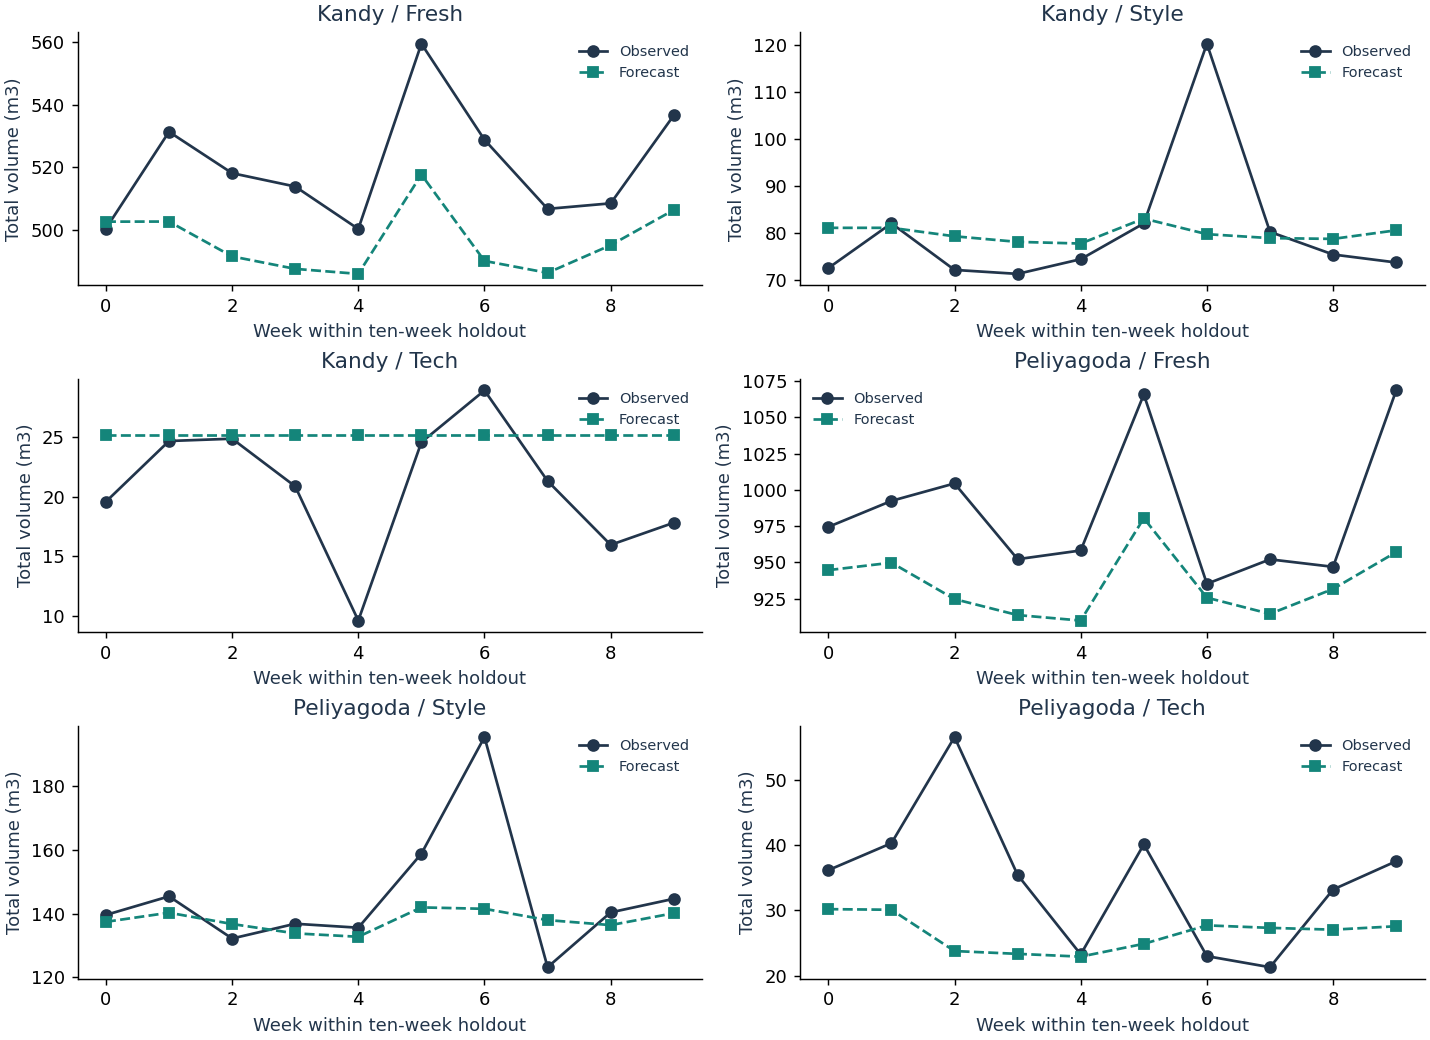

In [10]:
if (OUTPUT_DIR / 'reports/task2a_validation.png').exists():
    display(Image(filename=str(OUTPUT_DIR / 'reports/task2a_validation.png')))

### Forecasts that support a decision

Aggregate WAPE is volume-weighted and hides weaker Tech series. Negative per-series R² means the model has greater squared error than that holdout's hindsight mean; it does not mean the model has negative accuracy. We report both aggregate and segment results. The small new baseline experiment uses only the earlier ten-week folds; its modest/inconsistent results do not justify changing the verified submission.

Baseline tuning origins: ['2025-09-01', '2025-11-10'] | Excluded final holdout: 2026-01-19


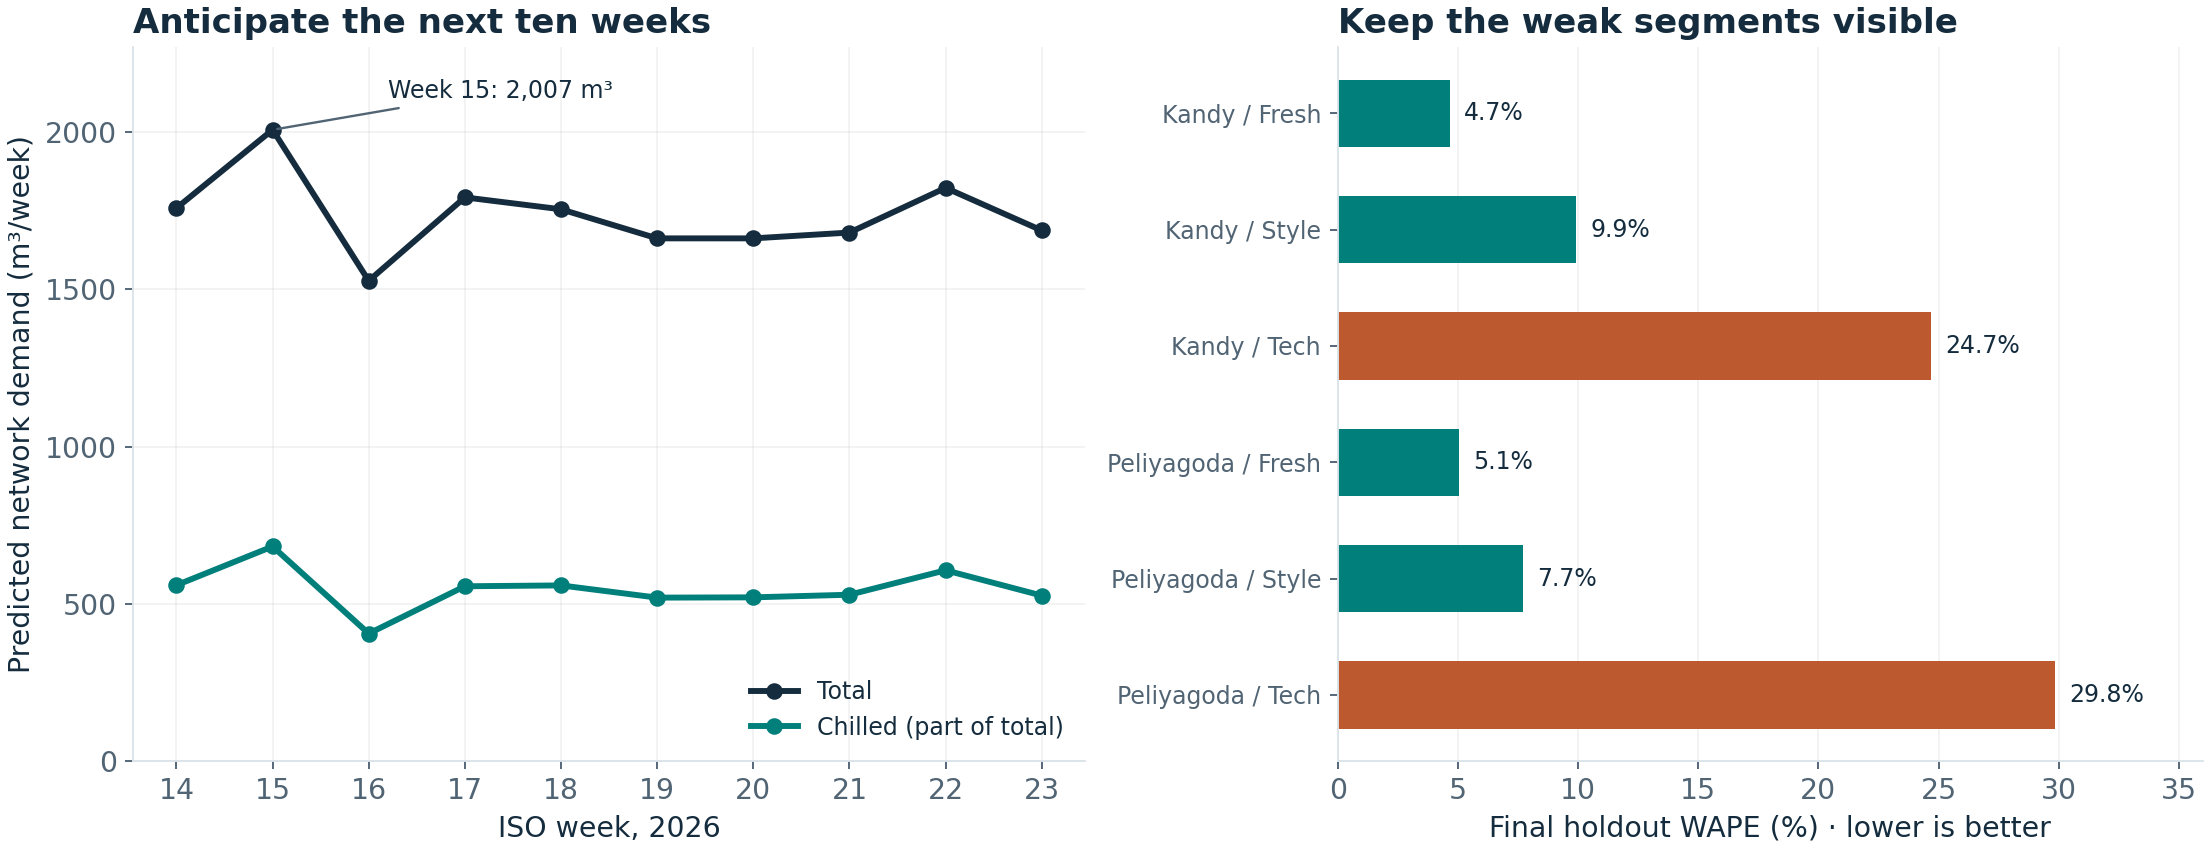

,depot,brand,n,mae,wape,r2,bias_m3
5,Kandy,Fresh,10,24.2226,0.0465,-1.2758,-23.7844
6,Kandy,Style,10,7.9825,0.0993,0.0142,-0.5737
7,Kandy,Tech,10,5.1374,0.2467,-0.7073,4.3907
8,Peliyagoda,Fresh,10,49.8111,0.0506,-0.6461,-49.8111
9,Peliyagoda,Style,10,11.1817,0.0770,0.0182,-7.3127
10,Peliyagoda,Tech,10,10.3410,0.2983,-0.7906,-8.1940


,depot,reference_model,reference_tuning_rmse,best_new_baseline,baseline_tuning_rmse,relative_rmse_improvement
0,Kandy,mean_13,10.8075,mean_13_prior_bias,10.7100,0.0090
1,Peliyagoda,ridge_1,8.1784,mean_26,9.2609,-0.1324


In [11]:
display(Image(filename=str(OUTPUT_DIR / 'reports/forecast_and_errors.png')))
segment = pd.read_csv(OUTPUT_DIR / 'reports/task2a_by_brand_depot.csv')
display(segment.query("target == 'total' and slice == 'depot+brand'")[['depot','brand','n','mae','wape','r2','bias_m3']].round(4))
experiment = json.loads((OUTPUT_DIR / 'reports/tech_baseline_experiment.json').read_text())
print('Baseline tuning origins:', experiment['origins'], '| Excluded final holdout:', experiment['excluded_final_holdout_start'])
display(pd.DataFrame(experiment['comparison']).drop(columns='action').round(4))

## 5. Allocation

CP-SAT assigns whole orders to available vehicles. Each trip uses one brand and district; capacity, depot, chilled and van restrictions are hard constraints. Per vehicle: at most two trips; Fresh time <=270 minutes and Style/Tech time <=480 minutes. Trip time is outbound + (orders−1)×inter-stop + published handling allowances. Priority points are transparent team policy, not official scoring. A separate maximum-order-count model supplies a comparison and bound.

In [12]:
if RUN_TRAINING:
    allocation = w.run_task2b(data, OUTPUT_DIR, args)
else:
    allocation = json.loads((OUTPUT_DIR / 'reports/task2b_summary.json').read_text())
display(pd.Series({k: allocation[k] for k in ['solver_status','served','deferred','served_volume_m3','deferred_volume_m3','relative_gap','official_checker']}))
display(pd.read_csv(OUTPUT_DIR / 'reports/task2b_trip_audit.csv'))
display(pd.read_csv(OUTPUT_DIR / 'reports/task2b_order_decisions.csv').query("decision == 'deferred'")[["order_ref","brand","order_volume_m3","priority_points","reason"]])

solver_status                                             OPTIMAL
served                                                         79
deferred                                                        6
served_volume_m3                                          328.298
deferred_volume_m3                                         81.566
relative_gap                                                  0.0
official_checker      FEASIBILITY: PASSED - every rule satisfied.
dtype: object

,scenario,vehicle_id,trip_id,brand,district,orders,volume_m3,volume_cap_m3,weight_kg,weight_cap_kg,outbound_min,inter_stop_min,service_min,trip_minutes
0,S1,VEH003,1,Fresh,Kurunegala,3,25.039,26.4,4593.3,5510,127,38,45.0,210.0
1,S1,VEH003,2,Fresh,Colombo,1,10.090,26.4,1696.6,5510,24,0,15.0,39.0
2,S1,VEH006,1,Fresh,Colombo,4,32.567,33.4,5953.2,6840,24,24,61.0,109.0
3,S1,VEH006,2,Fresh,Gampaha,3,28.720,33.4,5249.6,6840,37,18,46.0,101.0
4,S1,VEH007,1,Fresh,Kalutara,3,16.032,19.4,2930.2,3610,64,24,46.0,134.0
5,S1,VEH007,2,Fresh,Gampaha,3,19.337,19.4,3484.8,3610,37,18,45.0,100.0
6,S1,VEH008,1,Fresh,Gampaha,1,2.831,22.0,554.1,3800,37,0,16.0,53.0
7,S1,VEH008,2,Fresh,Colombo,4,12.039,22.0,2329.2,3800,24,24,62.0,110.0
8,S1,VEH009,1,Tech,Colombo,1,4.653,30.0,1566.3,5800,24,0,43.0,67.0
9,S1,VEH009,2,Fresh,Kurunegala,3,6.476,30.0,1242.4,5800,127,38,45.0,210.0


,order_ref,brand,order_volume_m3,priority_points,reason
56,S1-056,Fresh,3.754,580,deferred under priority policy while eligible ...
58,S1-058,Fresh,16.515,565,deferred under priority policy while eligible ...
64,S1-064,Fresh,6.784,565,deferred under priority policy while eligible ...
67,S1-067,Fresh,5.194,565,deferred under priority policy while eligible ...
78,S1-078,Style,40.660,130,individually infeasible: no available vehicle ...
83,S1-083,Fresh,8.659,825,deferred under priority policy while eligible ...


### Why all 85 orders cannot be served

There are four available refrigerated vehicles. Even allowing two full-volume trips for each, chilled demand exceeds optimistic capacity by 9.229 m³. This is a volume bound, not a sufficient feasibility test. Whole orders, district separation, van access, weight and time restrict packing further. A separate maximum-count solve proves that at most 79 orders can be served under the implemented competition rules.

Maximum-count proof: {'objective': 'count', 'solver_status': 'OPTIMAL', 'objective_value': 79.0, 'objective_bound': 79.0, 'relative_gap': 0.0, 'seconds': 2.011400101, 'served': 79, 'deferred': 6, 'priority_points_served': 35770, 'individually_impossible_orders': ['S1-078']}
Official checker: FEASIBILITY: PASSED - every rule satisfied.


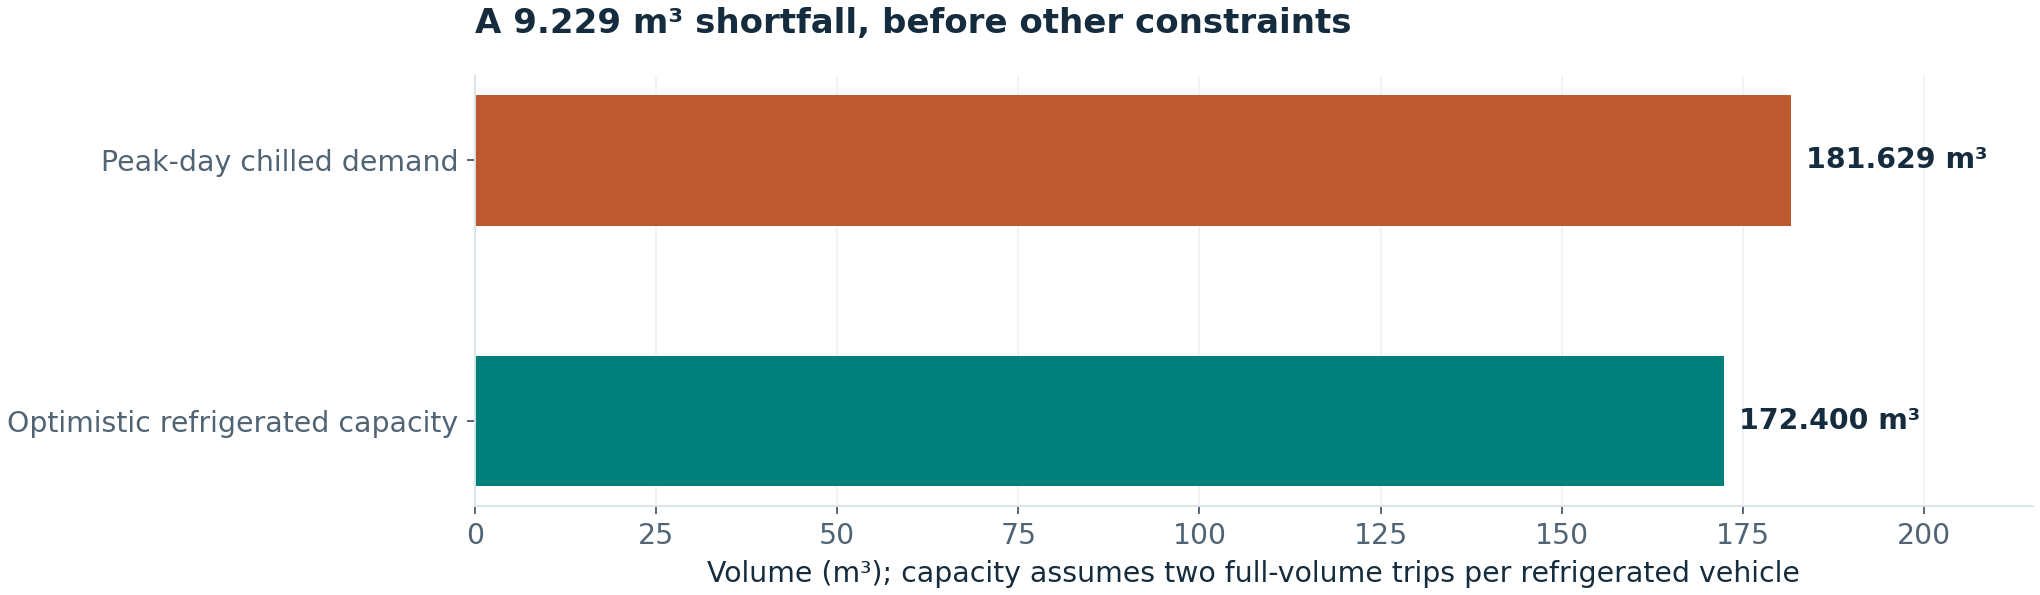

In [13]:
display(Image(filename=str(OUTPUT_DIR / 'reports/capacity_vs_demand.png')))
print('Maximum-count proof:', allocation['max_count_comparison'])
print('Official checker:', allocation['official_checker'])

### Same constraints, different business priorities

Fresh-first emphasizes perishable demand; fairness-first emphasizes yesterday's deferred orders and longer waits; balanced retains the verified submission weights. Only the objective weights change. Own-policy points have different scales, so use the common balanced-reference points for cross-policy comparisons. Fairness serves all 10 repeat-deferred orders but gives up two deliveries and 14.469 m³ of chilled volume. These policy scores are not official competition scores.

In [14]:
policies = pd.read_csv(OUTPUT_DIR / 'reports/policy_comparison.csv')
display(policies[['policy','served_orders','deferred_orders','chilled_volume_delivered_m3','own_policy_points','balanced_reference_points','repeat_deferred_orders_served','solver_status','solver_gap']].round(3))
display(pd.read_csv(OUTPUT_DIR / 'reports/policy_changed_orders.csv'))
print('All three alternative allocations passed the original organizer checker.')
frozen = json.loads((OUTPUT_DIR / 'reports/submission_freeze.json').read_text())
assert frozen['unchanged']
print('Verified submission CSVs unchanged:', frozen['unchanged'])

All three alternative allocations passed the original organizer checker.
Verified submission CSVs unchanged: True


,policy,served_orders,deferred_orders,chilled_volume_delivered_m3,own_policy_points,balanced_reference_points,repeat_deferred_orders_served,solver_status,solver_gap
0,Fresh-first,79,6,140.723,100300,35770,9,OPTIMAL,0.0
1,Fairness-first,77,8,126.254,60200,34900,10,OPTIMAL,0.0
2,Balanced,79,6,140.723,35770,35770,9,OPTIMAL,0.0


,order_ref,Balanced,Fairness-first,Fresh-first
0,S1-003,served,deferred,served
1,S1-056,deferred,served,deferred
2,S1-071,served,deferred,served
3,S1-073,served,deferred,served
4,S1-075,served,deferred,served
5,S1-083,deferred,served,deferred


## 6. Submission validation

The following checks preserve every supplied identifier, exact columns and row order. Demand outputs must satisfy zero <= chilled <= total, and non-Fresh chilled must equal zero.

In [15]:
validation = w.validate_submissions(data, OUTPUT_DIR)
display(pd.DataFrame(validation).T)
summary = w.write_run_summary(data, OUTPUT_DIR)
from IPython.display import HTML
display(HTML((OUTPUT_DIR / 'reports/run_summary.html').read_text()))


                          Metric                                                                       Result
     Task 1 chosen service model                              catboost_depth6 (72.0%) + hist_leaves31 (28.0%)
              Task 1 service MAE                                                                3.752 minutes
    Task 1 chosen lateness model xgboost_depth5 (47.5%) + catboost_depth6 (32.9%) + lightgbm_leaves31 (19.6%)
             Task 1 lateness AUC                                                                        0.975
  Task 2A total-volume blend MAE                                                                    18.113 m3
Task 2A chilled-volume blend MAE                                                                    14.300 m3
           Task 2B served orders                                                                           79
       Task 2B validation errors                                                                            0

Predicti

,rows,columns,valid
task1,5014,"[delivery_id, pred_service_min, pred_late_prob]",True
task2a,60,"[row_id, pred_total_volume_m3, pred_chilled_vo...",True
task2b,85,"[scenario, order_ref, outlet_id, decision, veh...",True


Task 1 chosen service model,catboost_depth6 (72.0%) + hist_leaves31 (28.0%)
Task 1 service MAE,3.752 minutes
Task 1 chosen lateness model,xgboost_depth5 (47.5%) + catboost_depth6 (32.9%) + lightgbm_leaves31 (19.6%)
Task 1 lateness AUC,0.975
Task 2A total-volume blend MAE,18.113 m3
Task 2A chilled-volume blend MAE,14.300 m3
Task 2B served orders,79
Task 2B validation errors,0


## 7. Saved-model inference

Final cell: load the saved model files, show actual test inputs and predictions for both prediction tasks, and verify that serialized-model inference reproduces the submission files. No training occurs in this cell.

In [16]:
print('TASK1 INPUTS')
display(data.read('task1_test_inputs.csv').head(5))
task1_predictions = w.inference_task1(data, OUTPUT_DIR / 'models')
print('TASK1 PREDICTIONS FROM SAVED MODELS')
display(task1_predictions.head(5))
print('TASK2A INPUTS')
display(data.read('task2a_test_inputs.csv').head(6))
task2a_predictions = w.inference_task2a(data, OUTPUT_DIR / 'models')
print('TASK2A PREDICTIONS FROM SAVED MODELS')
display(task2a_predictions.head(6))
for key, frame, file in [('delivery_id', task1_predictions, 'submission_task1.csv'), ('row_id', task2a_predictions, 'submission_task2a.csv')]:
    expected = pd.read_csv(OUTPUT_DIR / 'submissions' / file).set_index(key)
    actual = frame.set_index(key).reindex(expected.index)[expected.columns]
    np.testing.assert_allclose(actual, expected, atol=1e-7, rtol=0)
print('Both saved-model outputs reproduce the delivered prediction CSVs.')

TASK1 INPUTS
TASK1 PREDICTIONS FROM SAVED MODELS
TASK2A INPUTS
TASK2A PREDICTIONS FROM SAVED MODELS
Both saved-model outputs reproduce the delivered prediction CSVs.


,delivery_id,order_date,dispatch_date,dispatch_status,outlet_id,brand,district,depot,temp_requirement,order_units,order_weight_kg,order_volume_m3,route_id,seq_in_route,vehicle_id,vehicle_type,vehicle_temp,planned_arrival_time,window_open_time,window_close_time
0,ORD0092308,2026-02-16,2026-02-16,attempted,OUT001,Fresh,Colombo,Peliyagoda,ambient,11,92.1,0.501,R025229,0,VEH037,van,ambient,05:21,05:00,07:30
1,ORD0092309,2026-02-16,2026-02-16,attempted,OUT002,Fresh,Colombo,Peliyagoda,ambient,12,96.2,0.539,R025229,2,VEH037,van,ambient,06:10,05:30,08:00
2,ORD0092310,2026-02-16,2026-02-16,attempted,OUT003,Fresh,Colombo,Peliyagoda,ambient,13,89.8,0.472,R025229,1,VEH037,van,ambient,05:46,05:00,07:30
3,ORD0092311,2026-02-16,2026-02-16,attempted,OUT004,Fresh,Colombo,Peliyagoda,ambient,28,216.4,1.193,R025246,1,VEH021,truck,ambient,06:44,05:30,08:00
4,ORD0092312,2026-02-16,2026-02-16,attempted,OUT005,Fresh,Colombo,Peliyagoda,ambient,70,467.1,2.687,R025245,3,VEH012,truck,ambient,06:22,04:00,07:45


,delivery_id,pred_service_min,pred_late_prob
0,ORD0092308,7.408439,0.000084
1,ORD0092309,7.049250,0.000225
2,ORD0092310,11.401019,0.000178
3,ORD0092311,10.037015,0.002631
4,ORD0092312,12.491322,0.007459


,row_id,depot,brand,iso_year,iso_week
0,W0000,Kandy,Fresh,2026,14
1,W0001,Kandy,Style,2026,14
2,W0002,Kandy,Tech,2026,14
3,W0003,Peliyagoda,Fresh,2026,14
4,W0004,Peliyagoda,Style,2026,14
5,W0005,Peliyagoda,Tech,2026,14


,row_id,depot,brand,iso_year,iso_week,pred_total_volume_m3,pred_chilled_volume_m3
0,W0000,Kandy,Fresh,2026,14,510.238068,187.332064
1,W0001,Kandy,Style,2026,14,81.002128,0.000000
2,W0002,Kandy,Tech,2026,14,23.031846,0.000000
3,W0003,Peliyagoda,Fresh,2026,14,966.348213,371.701726
4,W0004,Peliyagoda,Style,2026,14,145.158791,0.000000
5,W0005,Peliyagoda,Tech,2026,14,32.731662,0.000000
